## **Exercise 5**

In this exercise, you'll implement multiple linear regression using an iterative approach similar to simple linear regression, but extended to handle multiple features. This will help you understand how to work with multiple predictors and how to generalize the concepts you've learned for simple linear regression.

Your task is to:

- a) Implement a function to calculate predictions using multiple features.
- b) Implement functions to calculate the gradients for each coefficient and the intercept.
- c) Create a fit function that uses these gradients to iteratively improve the coefficients.
- d) Compare your results with sklearn's LinearRegression.

Here's a template to get you started:

```python
import numpy as np
from sklearn.linear_model import LinearRegression as SklearnLinearRegression
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt

def predict(X, coeffs, intercept):
    # Implement prediction for multiple features
    pass

def calculate_gradients(X, y, coeffs, intercept):
    # Calculate gradients for coefficients and intercept
    # Return as a tuple (coefficient_gradients, intercept_gradient)
    pass

def fit(X, y, learning_rate=0.01, n_iterations=1000):
    n_samples, n_features = X.shape
    coeffs = np.zeros(n_features)
    intercept = 0
    
    for _ in range(n_iterations):
        y_pred = predict(X, coeffs, intercept)
        coef_grads, intercept_grad = calculate_gradients(X, y, coeffs, intercept)
        
        # Update coefficients and intercept
        coeffs -= learning_rate * coef_grads
        intercept -= learning_rate * intercept_grad
    
    return coeffs, intercept

# Generate a random regression problem
X, y = make_regression(n_samples=100, n_features=3, noise=0.1, random_state=42)

# Fit your model
coeffs, intercept = fit(X, y)

# Make predictions
y_pred = predict(X, coeffs, intercept)

# Compare with sklearn
sklearn_model = SklearnLinearRegression()
sklearn_model.fit(X, y)
y_pred_sklearn = sklearn_model.predict(X)

# Print results
print("Your model coefficients:", coeffs)
print("Your model intercept:", intercept)
print("Sklearn model coefficients:", sklearn_model.coef_)
print("Sklearn model intercept:", sklearn_model.intercept_)

# Calculate and print Mean Squared Error for both models
mse = np.mean((y - y_pred)**2)
mse_sklearn = np.mean((y - y_pred_sklearn)**2)
print(f"Your model MSE: {mse:.4f}")
print(f"Sklearn model MSE: {mse_sklearn:.4f}")

# Plot predictions vs actual values
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.scatter(y, y_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Your Model")

plt.subplot(1, 2, 2)
plt.scatter(y, y_pred_sklearn, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Sklearn Model")

plt.tight_layout()
plt.show()
```

In [ ]:
# Code here
import numpy as np
from sklearn.linear_model import LinearRegression as SklearnLinearRegression
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt

# a) Predict using multiple features
def predict(X, coeffs, intercept):
    return X @ coeffs + intercept

# b) Calculate gradients of mean squared error
def calculate_gradients(X, y, coeffs, intercept):
    n_samples = X.shape[0]
    errors = predict(X, coeffs, intercept) - y

    coefficient_gradients = (2 / n_samples) * (X.T @ errors)
    intercept_gradient = 2 * np.mean(errors)

    return coefficient_gradients, intercept_gradient

# c) Fit using gradient descent
def fit(X, y, learning_rate=0.01, n_iterations=1000):
    n_samples, n_features = X.shape
    coeffs = np.zeros(n_features)
    intercept = 0.0

    for _ in range(n_iterations):
        coef_grads, intercept_grad = calculate_gradients(
            X, y, coeffs, intercept
        )

        coeffs -= learning_rate * coef_grads
        intercept -= learning_rate * intercept_grad

    return coeffs, intercept

# Generate sample data
X, y = make_regression(
    n_samples=100,
    n_features=3,
    noise=0.1,
    random_state=42
)

# Fit your model and make predictions
coeffs, intercept = fit(X, y)
y_pred = predict(X, coeffs, intercept)

# d) Compare with sklearn
sklearn_model = SklearnLinearRegression()
sklearn_model.fit(X, y)
y_pred_sklearn = sklearn_model.predict(X)

print("Your model coefficients:", coeffs)
print("Your model intercept:", intercept)
print("Sklearn model coefficients:", sklearn_model.coef_)
print("Sklearn model intercept:", sklearn_model.intercept_)

# Calculate mean squared error
mse = np.mean((y - y_pred) ** 2)
mse_sklearn = np.mean((y - y_pred_sklearn) ** 2)

print(f"Your model MSE: {mse:.4f}")
print(f"Sklearn model MSE: {mse_sklearn:.4f}")

# Plot predictions vs actual values
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.scatter(y, y_pred, alpha=0.5)
plt.plot(
    [y.min(), y.max()], [y.min(), y.max()],
    'r--', lw=2
)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Your Model")

plt.subplot(1, 2, 2)
plt.scatter(y, y_pred_sklearn, alpha=0.5)
plt.plot(
    [y.min(), y.max()], [y.min(), y.max()],
    'r--', lw=2
)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Sklearn Model")

plt.tight_layout()
plt.show()

## **Exercise 6**

------------

_Note: For this exercise to work, you need to add animation support to VSCode. To do this, first run:_

```python
%pip install ipympl
```

_You only need to do this once, so comment the above line out when you're done so you don't reinstall it again. After you've installed `ipympl` restart your kernal and run the magic command:_

```python
%matplotlib ipympl
```

------------


In this exercise, you'll implement gradient descent for simple linear regression and create a visualization of the process. This will help you understand how the algorithm moves towards the optimal solution.

Your task is to:
- a) Implement the Mean Squared Error (MSE) function.
- b) Implement a single step of gradient descent.
- c) Implement the full gradient descent algorithm.
- d) Use the provided visualization code to see your algorithm in action.

Here's a template with the parts you need to implement:

```python
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation

# Generate some sample data
np.random.seed(0)
X = np.linspace(0, 10, 100).reshape(-1, 1)
y = 2 * X + 1 + np.random.randn(100, 1) * 0.5

def mse(X, y, w, b):
    # TODO: Implement Mean Squared Error function
    pass

def gradient_descent_step(X, y, w, b, learning_rate):
    # TODO: Implement a single step of gradient descent
    # Calculate gradients for w and b
    # Update w and b using the learning rate
    # Return the updated w and b
    pass

def gradient_descent(X, y, learning_rate=0.01, n_iterations=100):
    # TODO: Implement the full gradient descent algorithm
    # Initialize w and b
    # Create lists to store the history of w and b
    # Perform gradient descent for n_iterations
    # Return the history of w and b as numpy arrays
    pass

# Perform gradient descent
w_history, b_history = gradient_descent(X, y)

# Perform gradient descent
w_history, b_history = gradient_descent(X, y)

# Create mesh for 3D plot
w_range = np.linspace(-1, 4, 100)
b_range = np.linspace(-2, 5, 100)
W, B = np.meshgrid(w_range, b_range)
Z = np.array([mse(X, y, w, b) for w, b in zip(W.ravel(), B.ravel())]).reshape(W.shape)

# Create 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the MSE landscape
surf = ax.plot_surface(W, B, Z, cmap='viridis', alpha=0.6)
ax.set_xlabel('Weight (w)')
ax.set_ylabel('Bias (b)')
ax.set_zlabel('Mean Squared Error')
ax.set_title('Gradient Descent Optimization')

# Add a colorbar
fig.colorbar(surf, shrink=0.5, aspect=5)

# Function to update the plot in each animation frame
def update(frame):
    ax.clear()
    ax.plot_surface(W, B, Z, cmap='viridis', alpha=0.6)
    ax.set_xlabel('Weight (w)')
    ax.set_ylabel('Bias (b)')
    ax.set_zlabel('Mean Squared Error')
    ax.set_title(f'Gradient Descent Optimization (Iteration {frame})')
    
    # Plot the current position
    ax.scatter(w_history[frame], b_history[frame], mse(X, y, w_history[frame], b_history[frame]), 
               color='red', s=50, label='Current Position')
    
    # Plot the path taken
    ax.plot(w_history[:frame+1], b_history[:frame+1], 
            [mse(X, y, w, b) for w, b in zip(w_history[:frame+1], b_history[:frame+1])],
            color='red', linewidth=2, label='Optimization Path')
    
    ax.legend()

# Create the animation
anim = FuncAnimation(fig, update, frames=len(w_history), interval=100, repeat=False)

plt.show()

# Print final results
print(f"Final weight: {w_history[-1]:.4f}")
print(f"Final bias: {b_history[-1]:.4f}")
print(f"Final MSE: {mse(X, y, w_history[-1], b_history[-1]):.4f}")
```

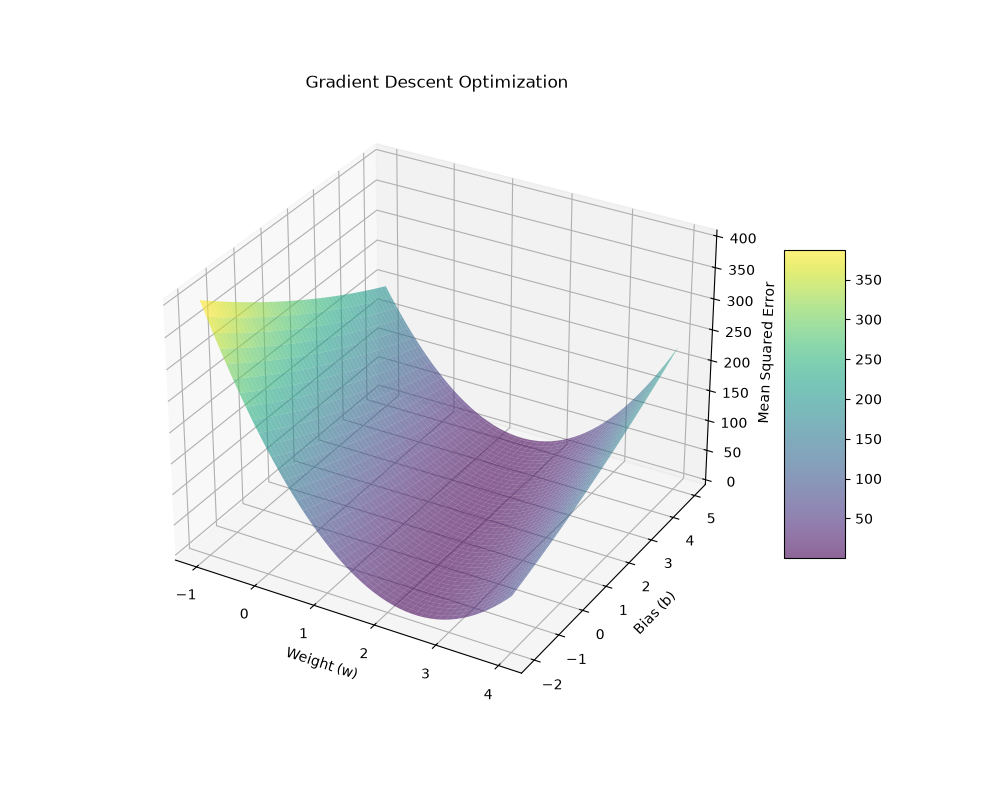

Final weight: 2.0572
Final bias: 0.6252
Final MSE: 0.3103


In [2]:
# Code here
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation

# Generate some sample data
np.random.seed(0)
X = np.linspace(0, 10, 100).reshape(-1, 1)
y = 2 * X + 1 + np.random.randn(100, 1) * 0.5


def mse(X, y, w, b):
    y_pred = w * X + b
    return np.mean((y_pred - y) ** 2)


def gradient_descent_step(X, y, w, b, learning_rate):
    errors = (w * X + b) - y

    w_gradient = 2 * np.mean(X * errors)
    b_gradient = 2 * np.mean(errors)

    w = w - learning_rate * w_gradient
    b = b - learning_rate * b_gradient

    return w, b


def gradient_descent(X, y, learning_rate=0.01, n_iterations=100):
    w = 0.0
    b = 0.0

    w_history = [w]
    b_history = [b]

    for _ in range(n_iterations):
        w, b = gradient_descent_step(X, y, w, b, learning_rate)

        w_history.append(w)
        b_history.append(b)

    return np.array(w_history), np.array(b_history)

# Perform gradient descent
w_history, b_history = gradient_descent(X, y)

# Perform gradient descent
w_history, b_history = gradient_descent(X, y)

# Create mesh for 3D plot
w_range = np.linspace(-1, 4, 100)
b_range = np.linspace(-2, 5, 100)
W, B = np.meshgrid(w_range, b_range)
Z = np.array([mse(X, y, w, b) for w, b in zip(W.ravel(), B.ravel())]).reshape(W.shape)

# Create 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the MSE landscape
surf = ax.plot_surface(W, B, Z, cmap='viridis', alpha=0.6)
ax.set_xlabel('Weight (w)')
ax.set_ylabel('Bias (b)')
ax.set_zlabel('Mean Squared Error')
ax.set_title('Gradient Descent Optimization')

# Add a colorbar
fig.colorbar(surf, shrink=0.5, aspect=5)

# Function to update the plot in each animation frame
def update(frame):
    ax.clear()
    ax.plot_surface(W, B, Z, cmap='viridis', alpha=0.6)
    ax.set_xlabel('Weight (w)')
    ax.set_ylabel('Bias (b)')
    ax.set_zlabel('Mean Squared Error')
    ax.set_title(f'Gradient Descent Optimization (Iteration {frame})')
    
    # Plot the current position
    ax.scatter(w_history[frame], b_history[frame], mse(X, y, w_history[frame], b_history[frame]), 
               color='red', s=50, label='Current Position')
    
    # Plot the path taken
    ax.plot(w_history[:frame+1], b_history[:frame+1], 
            [mse(X, y, w, b) for w, b in zip(w_history[:frame+1], b_history[:frame+1])],
            color='red', linewidth=2, label='Optimization Path')
    
    ax.legend()

# Create the animation
anim = FuncAnimation(fig, update, frames=len(w_history), interval=100, repeat=False)

plt.show()

# Print final results
print(f"Final weight: {w_history[-1]:.4f}")
print(f"Final bias: {b_history[-1]:.4f}")
print(f"Final MSE: {mse(X, y, w_history[-1], b_history[-1]):.4f}")